# Notebook 01 — Student Overview & Programme Performance

**Project:** Programme Health Intelligence: A Learning Analytics Case Study  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Author:** Megha Sinha  
**Date:** June 2026

---

## Objective

This notebook covers the first stage of the analysis pipeline:

1. Load and inspect all 7 OULAD dataset files
2. Assess and document data quality issues
3. Sample `studentVle.csv` (10% stratified sample) due to its size of 10.6M rows
4. Save cleaned and sampled files to `data/processed/` for use in subsequent notebooks
5. Produce an initial overview of student outcomes and programme performance

All findings are framed around the central business question:  
*What do pass, fail, distinction, and withdrawal rates look like across modules and demographic groups — and where are the concentration points?*

---
## 1. Import Libraries

In [2]:
# Standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load Data

In [3]:
# Define path to raw data folder
raw_path = '../data/raw/'

# Load 6 files
courses = pd.read_csv(raw_path + 'courses.csv')
assessments = pd.read_csv(raw_path + 'assessments.csv')
student_info = pd.read_csv(raw_path + 'studentInfo.csv')
student_registration = pd.read_csv(raw_path + 'studentRegistration.csv')
student_assessment = pd.read_csv(raw_path + 'studentAssessment.csv')
vle = pd.read_csv(raw_path + 'vle.csv')

print("All 6 files loaded successfully")
print("\nShape of each file:")
print(f"  courses:               {courses.shape}")
print(f"  assessments:           {assessments.shape}")
print(f"  student_info:          {student_info.shape}")
print(f"  student_registration:  {student_registration.shape}")
print(f"  student_assessment:    {student_assessment.shape}")
print(f"  vle:                   {vle.shape}")

All 6 files loaded successfully

Shape of each file:
  courses:               (22, 3)
  assessments:           (206, 6)
  student_info:          (32593, 12)
  student_registration:  (32593, 5)
  student_assessment:    (173912, 5)
  vle:                   (6364, 6)


---

## 3. Sample studentVle.csv

`studentVle.csv` contains 10,655,280 rows (454MB) and exceeds GitHub's file size limit.
A stratified 10% sample is taken by `code_module` and `code_presentation` to ensure all modules and cohorts are proportionally represented. The sample is saved to
`data/processed/` for use in all subsequent notebooks.

In [4]:
# Load studentVle in chunks to manage memory
print("Loading studentVle.csv — this may take a minute...")
student_vle_full = pd.read_csv(raw_path + 'studentVle.csv')
print(f"Full file loaded: {student_vle_full.shape[0]:,} rows")

# Stratified 10% sample by module and presentation
student_vle = (
    student_vle_full
    .groupby(['code_module', 'code_presentation'], group_keys=False)
    .apply(lambda x: x.sample(frac=0.1, random_state=42))
    .reset_index(drop=True)
)

print(f"Sampled file:    {student_vle.shape[0]:,} rows")
print(f"Reduction:       {100 - (student_vle.shape[0] / student_vle_full.shape[0] * 100):.1f}% smaller")

# Save sampled file to processed folder
processed_path = '../data/processed/'
os.makedirs(processed_path, exist_ok=True)
student_vle.to_csv(processed_path + 'studentVle_sampled.csv', index=False)
print(f"\nSampled file saved to data/processed/studentVle_sampled.csv")

# Free up memory
del student_vle_full
print("Full file removed from memory")

Loading studentVle.csv — this may take a minute...
Full file loaded: 10,655,280 rows
Sampled file:    1,065,529 rows
Reduction:       90.0% smaller

Sampled file saved to data/processed/studentVle_sampled.csv
Full file removed from memory


---

## 4. Data Quality Check

Inspect each file for missing values, data types, and any anomalies noted
during initial scanning. Issues identified here are documented in the BRD
Section 10 — Known Data Quality Issues.

In [5]:
# Check missing values across all files
files = {
    'courses': courses,
    'assessments': assessments,
    'student_info': student_info,
    'student_registration': student_registration,
    'student_assessment': student_assessment,
    'vle': vle,
    'student_vle (sampled)': student_vle
}

print("=== MISSING VALUES SUMMARY ===\n")
for name, df in files.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: No missing values")
    else:
        print(f"{name}:")
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"  {col}: {count:,} missing ({pct:.1f}%)")
    print()

=== MISSING VALUES SUMMARY ===

courses: No missing values

assessments:
  date: 11 missing (5.3%)

student_info:
  imd_band: 1,111 missing (3.4%)

student_registration:
  date_registration: 45 missing (0.1%)
  date_unregistration: 22,521 missing (69.1%)

student_assessment:
  score: 173 missing (0.1%)

vle:
  week_from: 5,243 missing (82.4%)
  week_to: 5,243 missing (82.4%)

student_vle (sampled): No missing values



---

### Data Quality Notes

| File | Issue | Rows Affected | Handling |
|---|---|---|---|
| assessments | date missing | 11 (5.3%) | Exam dates not scheduled — exclude from deadline analysis |
| student_info | imd_band missing | 1,111 (3.4%) | Treated as 'Unknown' category |
| student_registration | date_registration missing | 45 (0.1%) | Excluded from registration analysis |
| student_registration | date_unregistration missing | 22,521 (69.1%) | Expected — students who did not withdraw |
| student_assessment | score missing | 173 (0.1%) | Excluded from score analysis |
| vle | week_from / week_to missing | 5,243 (82.4%) | Not used in engagement analysis |

In [7]:
# Apply data quality fixes

# 1. Fill missing imd_band with 'Unknown'
student_info['imd_band'] = student_info['imd_band'].fillna('Unknown')

# 2. Drop rows with missing registration date (45 rows)
student_registration = student_registration.dropna(subset=['date_registration']).copy()

# 3. Drop rows with missing assessment score (173 rows)
student_assessment = student_assessment.dropna(subset=['score']).copy()

# 4. Flag withdrawn students explicitly in student_registration
student_registration['withdrew'] = student_registration['date_unregistration'].notna()

print("Data quality fixes applied:")
print(f"  imd_band nulls remaining:        {student_info['imd_band'].isnull().sum()}")
print(f"  registration rows after drop:    {len(student_registration):,}")
print(f"  student_assessment rows after:   {len(student_assessment):,}")
print(f"  students flagged as withdrew:    {student_registration['withdrew'].sum():,}")

Data quality fixes applied:
  imd_band nulls remaining:        0
  registration rows after drop:    32,548
  student_assessment rows after:   173,739
  students flagged as withdrew:    10,033


---

## 5. Student Outcomes Overview

*Business Question 1: What do pass, fail, distinction, and withdrawal rates look like
across modules and demographic groups — and where are the concentration points?*

In [8]:
# Overall outcome distribution
outcome_counts = student_info['final_result'].value_counts()
outcome_pct = student_info['final_result'].value_counts(normalize=True) * 100

outcome_summary = pd.DataFrame({
    'Count': outcome_counts,
    'Percentage': outcome_pct.round(1)
})

print("=== OVERALL STUDENT OUTCOMES ===\n")
print(outcome_summary)
print(f"\nTotal enrolments: {len(student_info):,}")
print(f"Unique students:  {student_info['id_student'].nunique():,}")

=== OVERALL STUDENT OUTCOMES ===

             Count  Percentage
Pass         12361       37.90
Withdrawn    10156       31.20
Fail          7052       21.60
Distinction   3024        9.30

Total enrolments: 32,593
Unique students:  28,785


---

### 5.1 Outcome Distribution — Overall

> **Key Finding:** 52.8% of enrolments do not result in a successful outcome
> (Pass or Distinction). Withdrawal alone accounts for 31.2% of all enrolments —
> nearly 1 in 3 students — making it the single largest driver of programme
> underperformance.

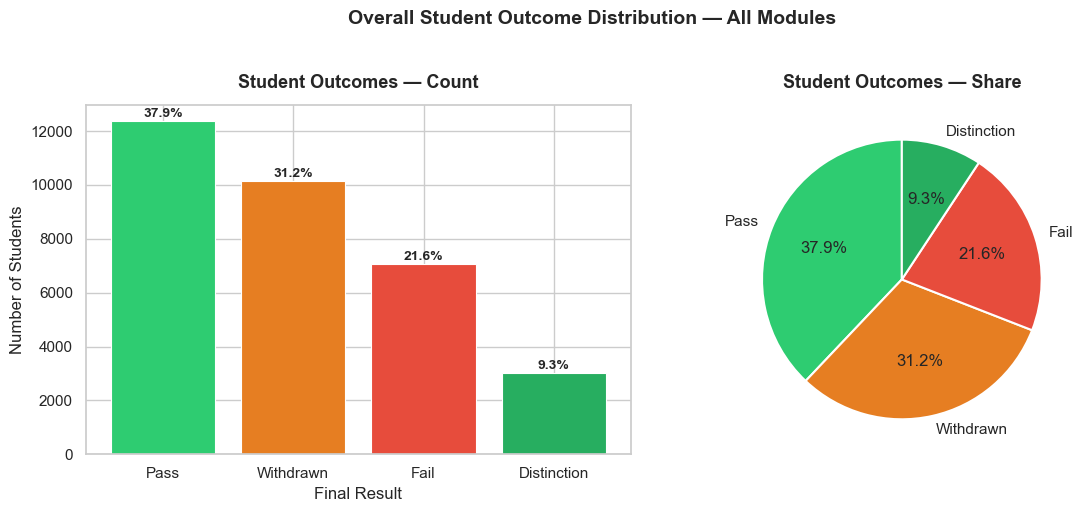

Chart saved to images/


In [9]:
# Define consistent colours for outcomes throughout the project
outcome_colours = {
    'Pass':       '#2ecc71',   # green
    'Distinction':'#27ae60',   # dark green
    'Fail':       '#e74c3c',   # red
    'Withdrawn':  '#e67e22'    # orange
}

# Map colours to outcome order
colours = [outcome_colours[o] for o in outcome_summary.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(outcome_summary.index, outcome_summary['Count'],
            color=colours, edgecolor='white', linewidth=0.8)
axes[0].set_title('Student Outcomes — Count', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Number of Students')
for i, (count, pct) in enumerate(zip(outcome_summary['Count'],
                                      outcome_summary['Percentage'])):
    axes[0].text(i, count + 150, f'{pct}%', ha='center',
                 fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(outcome_summary['Count'], labels=outcome_summary.index,
            colors=colours, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Student Outcomes — Share', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Overall Student Outcome Distribution — All Modules',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/01_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

---

### 5.2 Outcome Distribution — By Module

In [10]:
# Outcome counts by module
module_outcomes = (
    student_info
    .groupby(['code_module', 'final_result'])
    .size()
    .unstack(fill_value=0)
)

# Reorder columns consistently
col_order = [c for c in ['Pass', 'Distinction', 'Fail', 'Withdrawn']
             if c in module_outcomes.columns]
module_outcomes = module_outcomes[col_order]

# Calculate withdrawal rate per module for sorting
module_outcomes['withdrawal_rate'] = (
    module_outcomes['Withdrawn'] /
    module_outcomes.sum(axis=1) * 100
).round(1)

print("=== OUTCOMES BY MODULE ===\n")
print(module_outcomes.sort_values('withdrawal_rate', ascending=False))

=== OUTCOMES BY MODULE ===

final_result  Pass  Distinction  Fail  Withdrawn  withdrawal_rate
code_module                                                      
CCC           1180          498   781       1975            44.50
DDD           2227          383  1412       2250            35.90
FFF           2978          670  1711       2403            31.00
BBB           3077          677  1767       2388            30.20
EEE           1294          356   562        722            24.60
AAA            487           44    91        126            16.80
GGG           1118          396   728        292            11.50


---

### 5.3 Withdrawal Rate by Module

> **Key Finding:** Withdrawal rates vary dramatically across modules — from 11.5%
> (GGG) to 44.5% (CCC). This variation suggests module-specific factors are at
> play, not just student-level characteristics. CCC, DDD, and FFF are priority
> modules for operational intervention.

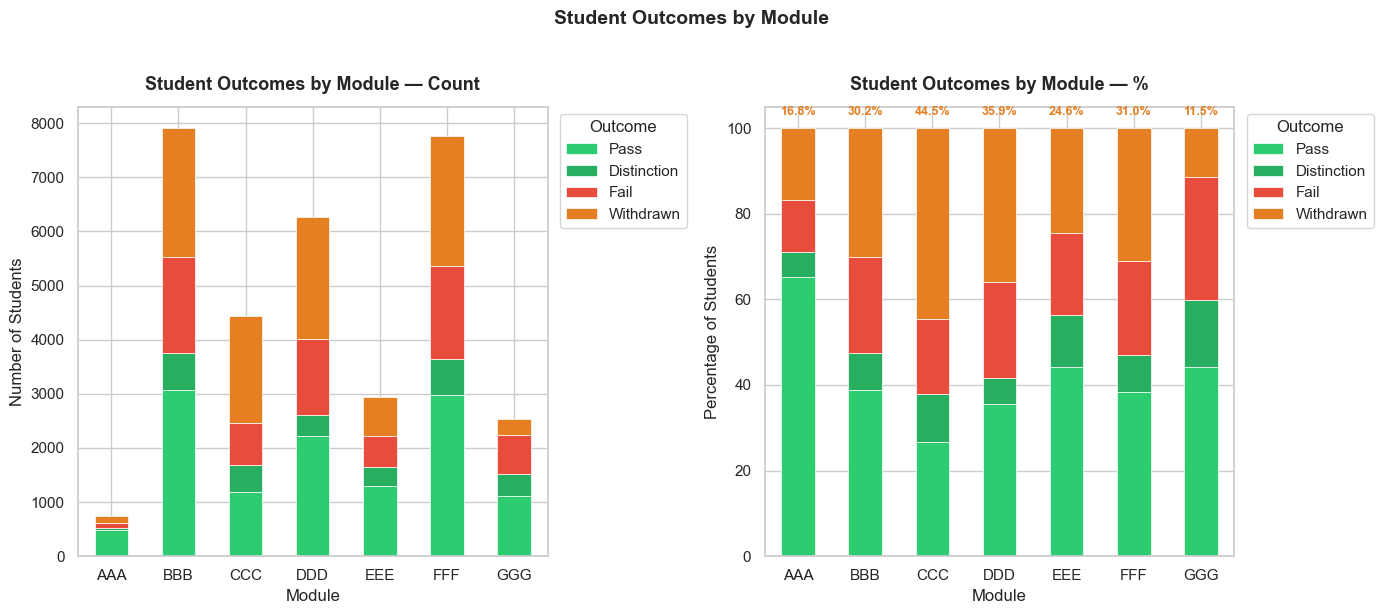

Chart saved to images/


In [11]:
# Stacked bar chart — outcomes by module
plot_data = module_outcomes[col_order].copy()
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — absolute counts
plot_data.plot(
    kind='bar',
    stacked=True,
    color=[outcome_colours[c] for c in col_order],
    ax=axes[0],
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Student Outcomes by Module — Count',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Module')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Right — percentage breakdown
plot_data_pct.plot(
    kind='bar',
    stacked=True,
    color=[outcome_colours[c] for c in col_order],
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5
)
axes[1].set_title('Student Outcomes by Module — %',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Module')
axes[1].set_ylabel('Percentage of Students')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Outcome', bbox_to_anchor=(1.01, 1), loc='upper left')

# Add withdrawal rate labels on percentage chart
for i, (module, row) in enumerate(module_outcomes.iterrows()):
    axes[1].text(i, 103, f"{row['withdrawal_rate']}%",
                ha='center', fontsize=9, fontweight='bold', color='#e67e22')

plt.suptitle('Student Outcomes by Module',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/02_outcomes_by_module.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

---

## 6. Save Cleaned Data

All cleaned DataFrames are saved to `data/processed/` for use in subsequent
notebooks. The raw files remain untouched in `data/raw/`.

In [12]:
# Save all cleaned files to processed folder
student_info.to_csv(processed_path + 'studentInfo_clean.csv', index=False)
student_registration.to_csv(processed_path + 'studentRegistration_clean.csv', index=False)
student_assessment.to_csv(processed_path + 'studentAssessment_clean.csv', index=False)
assessments.to_csv(processed_path + 'assessments_clean.csv', index=False)
vle.to_csv(processed_path + 'vle_clean.csv', index=False)
courses.to_csv(processed_path + 'courses_clean.csv', index=False)

print("Cleaned files saved to data/processed/:")
for f in os.listdir(processed_path):
    size = os.path.getsize(processed_path + f) / 1024
    print(f"  {f:<40} {size:>8.1f} KB")

Cleaned files saved to data/processed/:
  studentVle_sampled.csv                    30792.5 KB
  studentAssessment_clean.csv                4024.8 KB
  vle_clean.csv                               177.6 KB
  README.md                                     0.0 KB
  studentInfo_clean.csv                      2592.4 KB
  studentRegistration_clean.csv               997.0 KB
  assessments_clean.csv                         6.1 KB
  courses_clean.csv                             0.4 KB


---

## 7. Notebook Summary

### Key Findings

| Finding | Detail |
|---|---|
| Overall non-success rate | 52.8% of enrolments result in Fail or Withdrawal |
| Withdrawal rate | 31.2% — nearly 1 in 3 students withdraws |
| Highest risk module | CCC — 44.5% withdrawal rate |
| Lowest risk module | GGG — 11.5% withdrawal rate |
| Data quality | Minor issues identified and resolved — see Section 4 |

### What This Tells the Business

More than half of all enrolments do not result in a successful outcome. Withdrawal
is the single largest driver of this — and it is not evenly distributed across
modules. CCC, DDD, and FFF are significantly above the overall average and should
be prioritised for further investigation.

The variation between modules (11.5% to 44.5%) strongly suggests that
module-specific factors — not just student characteristics — are contributing
to withdrawals. This will be explored in Notebooks 2, 3, and 4.

### Files Produced

| File | Location |
|---|---|
| studentInfo_clean.csv | data/processed/ |
| studentRegistration_clean.csv | data/processed/ |
| studentAssessment_clean.csv | data/processed/ |
| assessments_clean.csv | data/processed/ |
| vle_clean.csv | data/processed/ |
| courses_clean.csv | data/processed/ |
| studentVle_sampled.csv | data/processed/ |

### Next Steps

- **Notebook 02** — Engagement Analysis: How does VLE activity correlate
  with final outcomes? Is there a minimum engagement threshold?
- **Notebook 03** — Dropout Timing: When do students withdraw — and is
  there a critical intervention window?
- **Notebook 04** — Assessment Performance: How early do assessment scores
  predict final outcomes?
- **Notebook 05** — At-Risk Identification: Which combination of factors
  is most associated with poor outcomes?